In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cd /content/drive/MyDrive/

In [3]:
!chmod 600 /content/drive/MyDrive/kaggle.json

In [4]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
 99% 2.27G/2.29G [00:16<00:00, 237MB/s]
100% 2.29G/2.29G [00:16<00:00, 151MB/s]


In [5]:
!unzip /content/chest-xray-pneumonia.zip

Streaming output truncated to the last 5000 lines.
  inflating: chest_xray/train/NORMAL/IM-0435-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0435-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0438-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0440-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0441-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0442-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0444-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0445-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0446-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0447-0001.jpeg  
  inflating:

In [6]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import os
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import random
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [7]:
train_dir = "/content/chest_xray/train"
test_dir = "/content/chest_xray/test"
val_dir = "/content/chest_xray/val"

In [8]:
transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10)
])

In [9]:
train_data = datasets.ImageFolder(train_dir, transform=transforms)
test_data = datasets.ImageFolder(test_dir, transform=transforms)
val_data = datasets.ImageFolder(val_dir, transform=transforms)

In [10]:
batch_size = 32
classes = train_data.classes
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

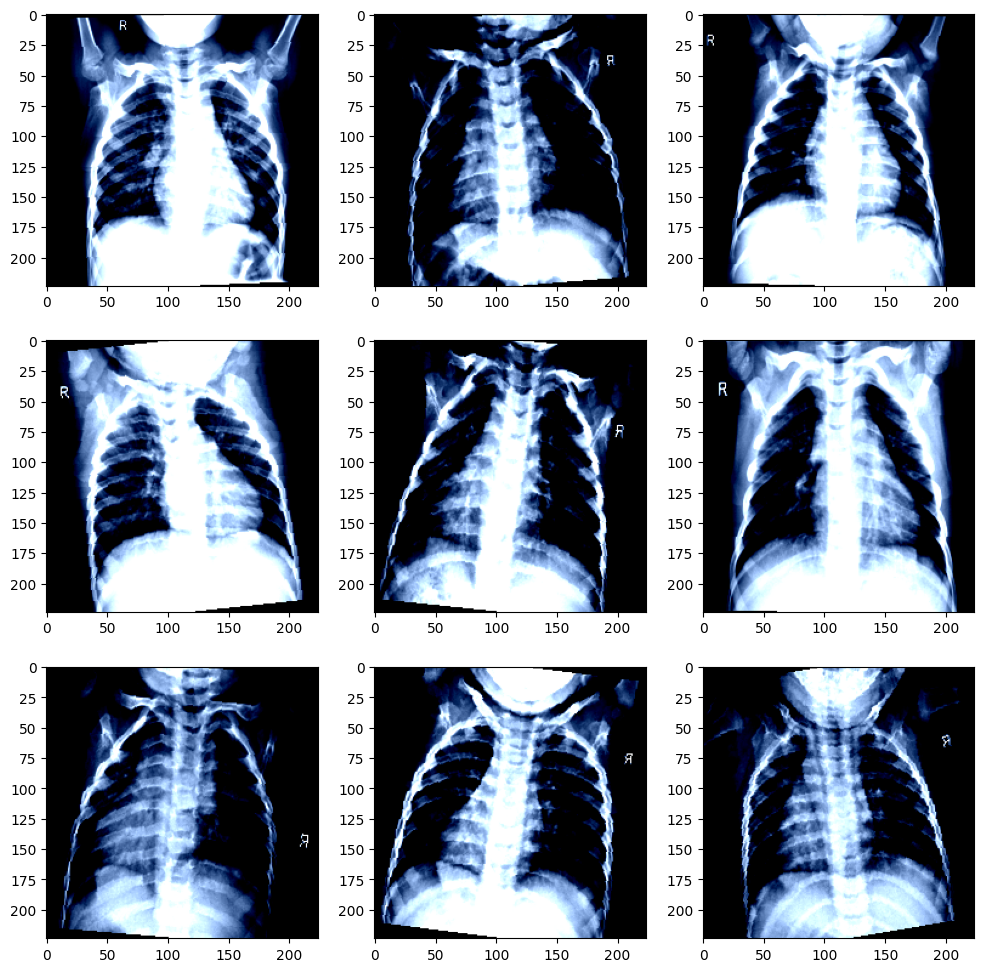

In [11]:
plt.figure(figsize=(12, 12))
for i in range(9):
    plt.subplot(3, 3, i+1)
    img, label = train_data[i]
    plt.imshow(img.permute(1, 2, 0))

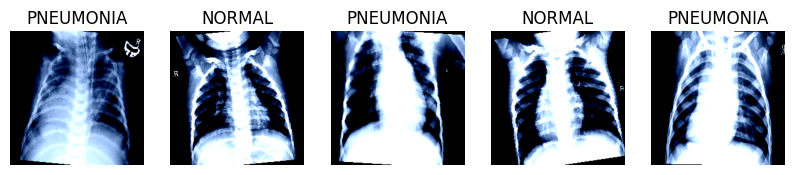

In [12]:
def imshow(img):
    img = img / 2 + 0.5  # Unnormalize
    plt.imshow(img.permute(1, 2, 0))  # Convert from Tensor (C, H, W) to (H, W, C)

# Get a batch of training data
data_iter = iter(train_loader)
images, labels = next(data_iter)

# Plot the first 5 images
fig, axes = plt.subplots(1, 5, figsize=(10, 5))
for i in range(5):
    axes[i].imshow(images[i].permute(1, 2, 0))
    axes[i].set_title(classes[labels[i]])
    axes[i].axis('off')
plt.show()


In [13]:
model = models.resnet50(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(classes))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 151MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [14]:
# Fine-tune deeper layers
for param in model.parameters():
    param.requires_grad = False  # Freeze all layers initially

for param in model.layer3.parameters():  # Unfreeze last few layers for fine-tuning
    param.requires_grad = True

# Modify the final layer
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(train_data.classes))
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [15]:
# Compute class weights for imbalanced dataset
class_counts = np.bincount([label for _, label in train_data.samples])
class_weights = torch.tensor(1.0 / class_counts, dtype=torch.float32)
criterion = nn.CrossEntropyLoss(weight=class_weights.to("cuda" if torch.cuda.is_available() else "cpu"))

In [16]:
# criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.fc.parameters(), lr=0.001, weight_decay=1e-4)
# Add learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3, verbose=True)

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [17]:
def evaluate_model(model, data_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

In [18]:
# Training loop with scheduler
num_epochs = 25
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Validation loss for scheduler
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            val_loss += criterion(outputs, labels).item()

    scheduler.step(val_loss / len(val_loader))
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader)}, Val Loss: {val_loss/len(val_loader)}")

Epoch 1/25, Loss: 0.29415166739123, Val Loss: 0.27508455514907837
Epoch 2/25, Loss: 0.2073229252834993, Val Loss: 0.8556519150733948
Epoch 3/25, Loss: 0.19884162567601613, Val Loss: 0.38696539402008057
Epoch 4/25, Loss: 0.17664221276534847, Val Loss: 0.5435271859169006
Epoch 5/25, Loss: 0.20150381198689982, Val Loss: 0.3456379175186157
Epoch 6/25, Loss: 0.1506592901823528, Val Loss: 0.40709641575813293
Epoch 7/25, Loss: 0.15735751455592598, Val Loss: 0.4849848449230194
Epoch 8/25, Loss: 0.15218889530451019, Val Loss: 0.2141987681388855
Epoch 9/25, Loss: 0.14381017847889405, Val Loss: 0.5899932384490967
Epoch 10/25, Loss: 0.14647104767111183, Val Loss: 0.27025899291038513
Epoch 11/25, Loss: 0.14667052521936, Val Loss: 0.5294452905654907
Epoch 12/25, Loss: 0.15122932073391654, Val Loss: 0.3316894769668579
Epoch 13/25, Loss: 0.14342077688936808, Val Loss: 0.27880820631980896
Epoch 14/25, Loss: 0.1458550100928984, Val Loss: 0.49963071942329407
Epoch 15/25, Loss: 0.14606090765332153, Val Lo

In [19]:
test_acc = evaluate_model(model, test_loader)
print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 83.65%


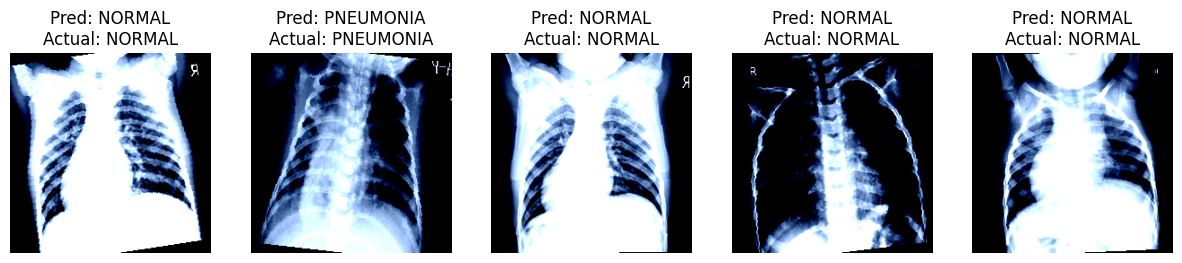

Validation Accuracy: 1.0000


In [30]:
from sklearn.metrics import accuracy_score
model.eval()  # evaluation mode

# Select random indices from the validation dataset
num_images = 5  # Number of images to display
# Changed: Sample indices from the validation data, not the directory
random_indices = random.sample(range(len(val_data)), num_images)

# Extract the selected images and labels
# Changed: Access images and labels from val_data directly
images = torch.stack([val_data[i][0] for i in random_indices])
labels = torch.tensor([val_data[i][1] for i in random_indices])

# Move images and labels to the same device as the model
images, labels = images.to(device), labels.to(device)

# Get model predictions
with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

# Convert images to CPU for visualization
images = images.cpu()
labels = labels.cpu()
preds = preds.cpu()

# Plot images with predicted and actual labels
fig, axes = plt.subplots(1, num_images, figsize=(15, 5))

for i in range(num_images):
    axes[i].imshow(images[i].permute(1, 2, 0))  # Convert tensor to image
    # Changed: Use val_data.classes to access class names
    axes[i].set_title(f"Pred: {val_data.classes[preds[i]]}\nActual: {val_data.classes[labels[i]]}")
    axes[i].axis("off")

plt.show()

# Compute accuracy
accuracy = accuracy_score(labels.numpy(), preds.numpy())
print(f"Validation Accuracy: {accuracy:.4f}")

In [21]:
torch.save(model.state_dict(), 'Pneumonia.pth')

In [22]:
# model = torch.load('Pneumonia.pth')